## Metrics Evaluation Lab

Throughout your early career as a Data Scientist you've spent most your time cleaning data, but now you are starting to build models and have come to realize the most important part about understanding any machine learning model (or any model, really) is understanding its weakness and vulnerabilities.

In doing so you've decided to practice on a dataset about mushrooms, because after all if you don't know how to evaluate a model thoroughly you'll be in real **truffle** (ha...ha) and introduce a approach that is new to you. 

Below I've build an initial **Decision Tree** model on the mushroom dataset to get you started. Think of the Decision Tree as your field guide – splitting mushrooms into categories one feature at a time. 

### Part 1: Load and Clean

Using the [mushroom dataset](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip) and the documentation below answer the provided question. 

- [Mushroom Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

*How well can we predict whether a mushroom is poisonous or edible based on its physical characteristics?* 



### Part 2: Build the model

This will most be provided for you, but some details you'll need to code yourself. 

### Part 3: Evaluate and assess

Consider where classification errors are occurring, is there a pattern? If so discuss this pattern and why you think this is the case. Use the confusion matrix to determine the pattern. 

### Keys to Success

- Using the evaluation metrics correctly: we are focusing on classification not regression
- Evaluation is not about the metrics per se, but what they mean; speaking through your question in light of the evaluation metrics is the primary objective of this lab. Think of yourself as a "model detective" that works to leave no stone unturned!
- Remember, be patient and double check your code or you might find yourself in real **shiitake** :)

---
## Initial Decision Tree Model – Starter Code

The code below walks you through an initial Decision Tree classifier on the mushroom dataset. Use it as a *spore*-ing board (sorry, not sorry) to complete the lab.

### Step 1 – Imports

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import metrics

### Step 2 – Load the Mushroom Dataset

We load the mushroom dataset directly. The target column is `type` (poisonous **p** vs edible **e**). 

For the full lab you may want to use the secondary mushroom dataset from UCI:
- [Download](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip)
- [Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

In [2]:
# Load the mushroom dataset
mushroom_url = (
    "https://raw.githubusercontent.com/stedy/"
    "Machine-Learning-with-R-datasets/master/mushrooms.csv"
)

mushroom_data = pd.read_csv(mushroom_url)

print(f'Dataset shape: {mushroom_data.shape}')
mushroom_data.head()

Dataset shape: (8124, 23)


,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Step 3 – Explore the Data

In [3]:
# Use the various exploration methods we covered in class to understand the dataset.
mushroom_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   type                      8124 non-null   str  
 1   cap_shape                 8124 non-null   str  
 2   cap_surface               8124 non-null   str  
 3   cap_color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill_attachment           8124 non-null   str  
 7   gill_spacing              8124 non-null   str  
 8   gill_size                 8124 non-null   str  
 9   gill_color                8124 non-null   str  
 10  stalk_shape               8124 non-null   str  
 11  stalk_root                8124 non-null   str  
 12  stalk_surface_above_ring  8124 non-null   str  
 13  stalk_surface_below_ring  8124 non-null   str  
 14  stalk_color_above_ring    8124 non-null   str  
 15

In [4]:
mushroom_data.describe()

,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [5]:
# Check for missing values
mushroom_data.isna().sum()

type                        0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64

### Step 4 – Clean & Prepare the Data



In [6]:
# Separate features (X) and target (y)
# Our target is 'type' – predicting poisonous (p) vs edible (e)
y = mushroom_data['type']
X = mushroom_data.drop('type', axis=1).copy()

In [7]:
# Calculate prevalence – how common is each class?
# This tells us what accuracy we'd get if we just guessed the majority class every time.
# If our model can't beat the prevalence, it's about as useful as a chocolate teapot...
# or a poisonous mushroom at a dinner party 

prevalence = y.value_counts(normalize = True)
print(prevalence)

type
e    0.517971
p    0.482029
Name: proportion, dtype: float64


### Collapse factor levels


Check for the levels of the categorical features
This helps us understand the diversity of our features and how they might influence the model 
and if we need to collapse rare categories to avoid overfitting on tiny groups of mushrooms, don't use 
a for loop, `nunique()` will give us the unique values for each column at once, its a function of the dataframe, 
not a function of the column, so we can call it on the whole dataframe and it will return the 
unique values for each column in one go


Then use data wrangler or another method to identify features that need to be collapsed, 
for example if a feature has 10 levels but 9 of them are very rare, 
we might want to collapse those 9 levels into an "other" 
category to avoid overfitting on those rare categories, this is especially 
important for decision trees which can easily overfit on rare categories

In [ ]:
# Collapse rare categories in the 'habitat' feature
# This is a common preprocessing step to avoid overfitting on rare categories,
# especially important for decision trees which can easily overfit on rare categories
# X['habitat'] = X['habitat'].replace(['u', 'd'], 'other') # in this example we are simply replacing the 'u' and 'd' 

# categories with 'other', but in a real analysis we would want to look at the distribution of the categories and 
# decide which ones to collapse based on their frequency and importance to the model, 
# this is just an example to show how to do it, 
# you would need to adjust it based on your specific dataset and analysis needs

# Other functions that might be helpful for this step include value_counts(), where() and isin() 
# sample code for how that might look, but again you would need to adjust it based on your specific dataset and analysis needs

# top_cats = df['col'].value_counts().nlargest(2).index # this would give us the top 2 most common categories in the 'col' feature,
# df['new_col'] = df['col'].where(df['col'].isin(top_cats), 'Other') # this would create a new column 'new_col' where the 
# values are the same as 'col' for the top 2 categories,and 'Other' for all other categories,
# this is a common way to collapse rare categories into an 'Other' category,
# but again you would need to adjust it based on your specific dataset and analysis needs.

In [16]:
# unique categories in each column
X.nunique().sort_values(ascending = False)

gill_color                  12
cap_color                   10
stalk_color_below_ring       9
spore_print_color            9
stalk_color_above_ring       9
odor                         9
habitat                      7
population                   6
cap_shape                    6
stalk_root                   5
ring_type                    5
stalk_surface_above_ring     4
cap_surface                  4
veil_color                   4
stalk_surface_below_ring     4
ring_number                  3
gill_attachment              2
bruises                      2
gill_size                    2
gill_spacing                 2
stalk_shape                  2
veil_type                    1
dtype: int64

In [34]:
# checking frequency of categories in 'gill_color', but I checked the frequency in all the columns, just took too much space to show here. 
print(X['gill_color'].value_counts())

# collapsing categories
X['gill_color'] = X['gill_color'].replace(['e', 'y', 'o', 'r'], 'other')
X['cap_color'] = X['cap_color'].replace(['c', 'u', 'r', 'b', 'p'], 'other')
X['stalk_color_below_ring'] = X['stalk_color_below_ring'].replace(['g', 'n', 'o', 'b', 'e', 'c', 'y'], 'other')
X['spore_print_color'] = X['spore_print_color'].replace(['y', 'u', 'r', 'b', 'o'], 'other')
X['stalk_color_above_ring'] = X['stalk_color_above_ring'].replace(['c', 'y', 'e', 'g', 'n', 'b', 'o'], 'other')
X['odor'] = X['odor'].replace(['y', 's', 'a', 'l', 'p', 'c', 'm'], 'other')
X['habitat'] = X['habitat'].replace(['u', 'm', 'w', 'l'], 'other')
X['population'] = X['population'].replace(['c', 'n', 'a'], 'other')
X['cap_shape'] = X['cap_shape'].replace(['k', 'b', 's', 'c'], 'other')
X['stalk_root'] = X['stalk_root'].replace(['c', 'r'], 'other')
X['ring_type'] = X['ring_type'].replace(['n', 'f'], 'other')
X['stalk_surface_above_ring'] = X['stalk_surface_above_ring'].replace(['y', 'f'], 'other')
X['veil_color'] = X['veil_color'].replace(['y', 'o', 'n'], 'other')
X['stalk_surface_below_ring'] = X['stalk_surface_below_ring'].replace(['y', 'f'], 'other')

gill_color
b        1728
p        1492
w        1202
n        1048
g         752
h         732
u         492
k         408
other     270
Name: count, dtype: int64


### Step 5 – Partition the Data

We split our fungi into training, tuning, and test sets.

In [35]:
# 70 / 15 / 15 split – train / tune / test
# Stratify keeps the same ratio of edible:poisonous in each set, which is important for evaluation.

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)
X_tune, X_test, y_tune, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42, stratify = y_temp)

In [41]:
categorical_features = X.select_dtypes(include='object').columns.tolist() # creating a list of the categorical features, 
# this will be used later for preprocessing in the pipeline, in this example we are using a ordinal encoder 
# which can handle categorical features without needing to one-hot encode them,
# but we need to tell the pipeline which features are categorical so it knows to apply the ordinal encoder to 
# those features and not to the numeric features (if we had any).


# Create a LabelEncoder for the target variable
le_target = LabelEncoder()
le_target.fit(y)

# Build decision tree pipeline with OrdinalEncoder preprocessing
dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer( #note the preprocessor and the classifier on the same level of the pipeline, 
        #this is important because we want to make sure that the preprocessing is applied to the 
        # training data during cross-validation and grid search, if we put the preprocessor inside the classifier 
        # it would only be applied to the test data and not the training data, which would lead to data leakage and overfitting
        transformers=[
            ('ordinal', OrdinalEncoder(), categorical_features) # applying the ordinal encoder to the categorical features, 
            #this will convert the categorical features into numeric 
            # values that can be used by the decision tree classifier
        ],
        remainder='passthrough'
    )),
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=42, criterion='gini'))
])

# Evaluate with 5-fold cross-validation on training data
cv_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


# Fit final model on full training data
dt_pipeline.fit(X_train, y_train)

# Calculate accuracies
train_accuracy = dt_pipeline.score(X_train, y_train)
tune_accuracy = dt_pipeline.score(X_tune, y_tune)

print(f"pipeline training accuracy: {train_accuracy:.4f}")
print(f"pipeline tuning accuracy: {tune_accuracy:.4f}")


/tmp/ipykernel_2171/2805597106.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include='object').columns.tolist() # creating a list of the categorical features,


pipeline training accuracy: 0.9727
pipeline tuning accuracy: 0.9770


---
## Evaluation Metrics

Time to find out how well our tree knows its fungi.

In [ ]:
# Generate predictions and predicted probabilities on the tuning set and pass into variables
# Think of probabilities as how confident our tree is, example below
#dt_pred = dt_model.predict(X_tune)
#dt_prob = dt_model.predict_proba(X_tune)

# Bundle everything into a tidy DataFrame
#results = pd.DataFrame({
#    'target': y_tune,
#    'pred': dt_pred,
#    'prob_edible': dt_prob[:, 0], # first column
#    'prob_poisonous': dt_prob[:, 1] # second column
#})

In [42]:
# generate predictions and predicted probabilities
dt_pred = dt_pipeline.predict(X_tune)
dt_prob = dt_pipeline.predict_proba(X_tune)

# dataframe
results = pd.DataFrame({
    'target': y_tune,
    'pred': dt_pred,
    'prob_edible': dt_prob[:, 0],
    'prob_poisonous': dt_prob[:, 1] 
})

print(results.head())

     target pred  prob_edible  prob_poisonous
3331      p    p     0.057314        0.942686
4038      p    p     0.000000        1.000000
3619      e    e     0.980329        0.019671
6062      p    p     0.057314        0.942686
5880      p    p     0.000000        1.000000


#### Confusion Matrix

The confusion matrix shows us where our model is getting confused, build a confusion matrix and see how the model is performing. Give a 2 sentence summary on what you see. 

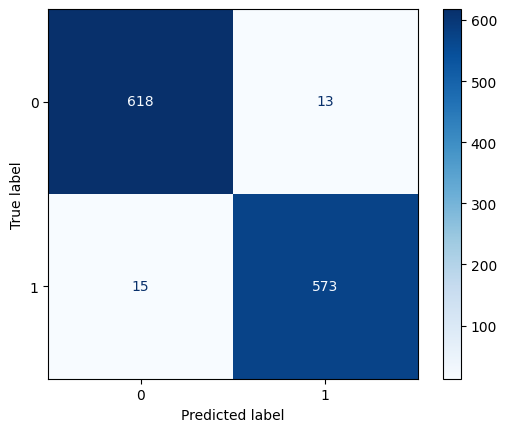

In [ ]:
cm = metrics.confusion_matrix(results['target'], results['pred'])
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Blues')

# The model is performing well as a vast majority of the data falling on the diagonal of the confusion matrix. Most mushrooms are being correctly
# classified and there are very few false positives (poisonous mushrooms classified as edible). 

#### True Positive Rate (Sensitivity / Recall) & False Positive Rate

In [53]:
tn, fp, fn, tp = cm.ravel()

# TPR (True Positive Rate) = Recall = Sensitivity
tpr = tp / (tp + fn)
# Of all the actually poisonous mushrooms, how many did we correctly flag?
# 97.45%

# FPR (False Positive Rate) = how many safe mushrooms did we wrongly accuse?
fpr = fp / (fp + tn)
# 2.06%

print(f"True Positive Rate (Recall): {tpr:.4f}")
print(f"False Positive Rate: {fpr:.4f}")

True Positive Rate (Recall): 0.9745
False Positive Rate: 0.0206


#### Classification Report

In [54]:
# Full classification report – the tasting menu of evaluation metrics 
print(metrics.classification_report(results.target, results.pred))

              precision    recall  f1-score   support

           e       0.98      0.98      0.98       631
           p       0.98      0.97      0.98       588

    accuracy                           0.98      1219
   macro avg       0.98      0.98      0.98      1219
weighted avg       0.98      0.98      0.98      1219



#### ROC Curve & AUC

The ROC curve plots TPR vs FPR at every threshold. AUC (Area Under the Curve) summarises it in one number – 1.0 is perfect, 0.5 is a coin flip.  

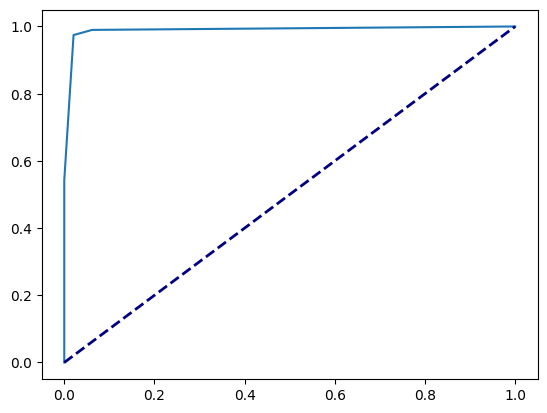

In [61]:
fpr, tpr, thresholds = metrics.roc_curve(y_tune, dt_prob[:, 1], pos_label='p')

# 2. Calculate the Area Under the Curve (AUC)
roc_auc = metrics.auc(fpr, tpr)

# 3. Plotting the results
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.show()

### Write a summary of what you found based on the evaluation measures. Include where have you noticed some issues with the model and What metrics do you think we should pay most attention to given the target variable.

 - Do you think we should adjust the threshold from the default value or not? Why or why not?


 - Based on the permformance metrics, the decision tree is quite strong for this dataset. I used `max_depth` to prevent overfitting, but the model still had high accuracy showing that there is very likely a relationship between mushroom features and toxicity. The model has high precision and recall for both classes. The most critical metric is recall for the posionous class since failing to classify a toxic mushroom is much worse than misidentifying a safe one. 
 - I recommend lowering the classification threshold. This is because the consequences of a false negative/low recall are much worse than a false positive. Adjusting the classification threshold ensures that if the model is even a little uncertain, it defaults to poisonous.

---

You now have a working Decision Tree baseline.

**Attempt the Bonus** 5 points each:

Pick a metric we haven’t covered (e.g., Matthews Correlation Coefficient, Precision-Recall AUC, Cohen’s Kappa) and discuss it.

Choose a model we have not present in class and see if the evaluation is better or worse - be specific about the metric you are using for comparison and why the model seems to fit better or worse. 



**Matthews Correlation Coefficient:** a metric for evaluating binary classification models and takes into account all four squares of the confusion matrix. 

**Random Forest:** combines mutltiple decision trees and lets them vote on the result. 

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef

rf_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('ordinal', OrdinalEncoder(), categorical_features)
        ],
        remainder='passthrough'
    )),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_tune)

mcc_score = matthews_corrcoef(y_tune, rf_pred)
print(f"Random Forest MCC: {mcc_score:.4f}")

Random Forest MCC: 1.0000


**Cohen's Kappa:** measures how much better a model is performing than a model that just guesses based on class distributions. 
- if n% of mushrooms are edible, a model could get n% accuracy just by guessing "edible" every time.

**Support Vector Machines:** finds a hyperplane that creates the widest possible gap between edible and poisonous mushrooms. 

In [65]:
from sklearn.svm import SVC
from sklearn.metrics import cohen_kappa_score

# Update the pipeline to use Support Vector Classifier
svm_pipeline = Pipeline([
    ('preprocessor', dt_pipeline.named_steps['preprocessor']),
    ('classifier', SVC(kernel='linear', probability=True, random_state=42))
])

# Fit and Predict
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_tune)

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(y_tune, svm_pred)
print(f"SVM Cohen’s Kappa: {kappa:.4f}")

SVM Cohen’s Kappa: 0.9458
